In [98]:
#S=SUCEPTIBLES
#E=EXPUESTOS : PERSONAS QUE HAN SIDO INFECTADAS PERO NO SON CONTAGIOSAS, ESTÁN EN PERIODO DE INCUBACIÓN
#I=INFECTADOS
#R=RECUPERADOS

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [100]:
# Parametros SEIR
N = 100000 # Población total
I0 = 1 # Infectados iniciales
E0 = 0 # Expuestos iniciales
R0 = 0 # Recuperados iniciales
S0 = N - I0 - E0 # Suceptibles iniciales

In [101]:
# Parametros del modelo
beta = 0.4 # Tasa de transmisión
sigma = 1/5 # Tasa de incubación (periodo de 5 días)
gamma = 1/10 # Tasa de recuperación
dias = 225


In [102]:
# definir ecuaciones diferenciales
def seir_model(y, t, N, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]

In [103]:
# vector de tiempo
t = np.linspace(0, dias, dias)

In [104]:
# condiciones iniciales
y0 = [S0, E0, I0, R0]

In [105]:
# resolver ecuaciones diferenciales
solution = odeint(seir_model, y0, t, args=(N, beta, sigma, gamma))

In [106]:
# Extraer resultados
S, E, I, R = solution.T
S

array([99999.        , 99998.61282849, 99998.23601184, 99997.84706234,
       99997.428706  , 99996.96661868, 99996.44790633, 99995.8600557 ,
       99995.19017817, 99994.42443067, 99993.54753716, 99992.54235954,
       99991.38948247, 99990.0667868 , 99988.54899229, 99986.80715357,
       99984.80809516, 99982.51377199, 99979.88054126, 99976.85833081,
       99973.38968762, 99969.40868812, 99964.83968939, 99959.59589819,
       99953.57773085, 99946.67093388, 99938.74443065, 99929.64785441,
       99919.20872235, 99907.22920213, 99893.48240985, 99877.70817516,
       99859.60819961, 99838.84052365, 99815.0132083 , 99787.67712569,
       99756.31773891, 99720.34574096, 99679.08640582, 99631.76749154,
       99577.50552072, 99515.29024954, 99443.96712491, 99362.2175186 ,
       99268.53652407, 99161.20810397, 99038.27738601, 98897.5199342 ,
       98736.40786856, 98552.07277471, 98341.2654579 , 98100.31274185,
       97825.07172459, 97510.88219097, 97152.51824487, 96744.14070449,
      

In [107]:
# determinar valores clave
dia_maximo_infectados = np.argmax(I)
max_infectados_seir = int(I[dia_maximo_infectados])
print(f"El día máximo de infectados será el día {dia_maximo_infectados} y en este momento estaran infectadas {max_infectados_seir} personas")

El día máximo de infectados será el día 90 y en este momento estaran infectadas 26037 personas


In [108]:
#Valores finales
recuperados_finales = int(R[-1])
nunca_infectados = int(S[-1])

print( int(I[-1]))

0


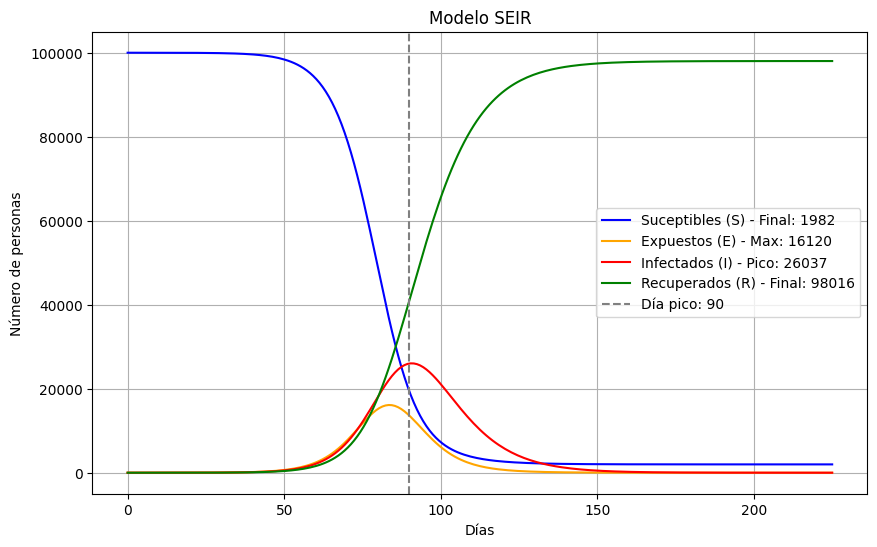

In [109]:
#graficar resultados
plt.figure(figsize=(10,6))
plt.plot(t, S, label=f'Suceptibles (S) - Final: {int(S[-1])}', color="blue")
plt.plot(t, E, label=f'Expuestos (E) - Max: {int(max(E))}', color="orange")
plt.plot(t, I, label=f'Infectados (I) - Pico: {max_infectados_seir}', color="red")
plt.plot(t, R, label=f'Recuperados (R) - Final: {int(R[-1])}', color="green")
plt.axvline(x=dia_maximo_infectados, color='gray', linestyle='--', label=f'Día pico: {dia_maximo_infectados}')
plt.xlabel('Días')
plt.ylabel('Número de personas')
plt.title('Modelo SEIR')
plt.legend()
plt.grid(True)
plt.show()
